Carregando circuitos que serão comparados

In [1]:
import pathlib
import landauer.entropy as entropy
import landauer.parse as parse

def read_benchmark(benchmark, circuit):
    benchmark_tree = pathlib.Path() / '..' / 'benchmark' / 'aig' / benchmark / (circuit + '.json')
    benchmark_entropy = pathlib.Path() / '..' / 'benchmark' / 'entropy' / benchmark / (circuit + '.json')

    with open(benchmark_tree) as f:
        aig = parse.deserialize(f.read())

    with open(benchmark_entropy) as f:
        entropy_data = entropy.deserialize(f.read())

    return aig, entropy_data

aig, entropy_data = read_benchmark('mcnc', 'newtpla')

In [2]:
import landauer.algorithms.naive as naive

energy_oriented = naive.naive(aig, naive.Strategy.ENERGY_ORIENTED)
depth_oriented = naive.naive(aig, naive.Strategy.DEPTH_ORIENTED)

In [3]:
import landauer.algorithms.genetic as genetic

param_map = {
    'name': 'Parametrização Padrão',
    'w_energy': 1,
    'w_delay': 0,
    'n_generations': 2000,
    'n_initial_individuals': 40,
    'reproduction_rate': 1,
    'mutation_rate': 0.2,
    'mutation_intensity': 0.1,
    'elitism_rate': 0.05,
    'crossover_strategy': genetic.CrossoverStrategy.GATE
}

results = genetic.genetic(aig, entropy_data, param_map)
genetic_result = results['pareto_info']['middle'].forwarding

==== Melhor Solução ====
Energia: 30.07848145786063(0.5495305071833201%)
Delay: 20(-0.4285714285714286%)


In [14]:
import landauer.placement as placement

genetic_result = placement.place(aig, results['pareto_info']['middle'].assignment)

Avaliando perdas de entropia

In [15]:
import landauer.evaluate as evaluate

eval_original = evaluate.evaluate(aig, entropy_data)
eval_energy = evaluate.evaluate(energy_oriented, entropy_data)
eval_depth = evaluate.evaluate(depth_oriented, entropy_data)
eval_genetic = evaluate.evaluate(genetic_result, entropy_data)

print(eval_genetic)

{'gates': {1: 1.188721875540867, 2: 1.188721875540867, 3: 1.285266182301252, 4: 0.34010966772274975, 5: 0.49859019944713223, 6: 0.41755824742105707, 7: 0.2825506661479784, 8: 1.1421576785011673, 9: 0.5, 10: 0.14765615185724557, 11: 0.4298893331585696, 12: 0.2942089203011633, 13: 1.1481147037406454, 14: 1.0924648366358447, 15: 0.5, 16: 0.40563906222956647, 17: 0.27178222159979826, 18: 1.2308209457501023, 19: 0.3789392312691977, 20: 0.24901394326723825, 21: 0.5, 22: 0.40563906222956647, 23: 0.0, 24: 0.8568441215341678, 25: 0.0, 26: 0.40563906222956647, 27: 0.0, 28: 0.40563906222956647, 29: 0.2500000000000001, 30: 0.75, 31: 0.5, 32: 0.40563906222956647, 33: 0.5, 34: 1.2677136812595364, 35: 0.2500000000000001, 36: 1.140449722160675, 37: 0.0, 38: 0.0, 39: 0.3034220607670839, 40: 1.2707758273111347, 41: 0.0, 42: 0.0, 43: 1.285266182301252, 44: 0.1888076243739506, 45: 0.37893923126919793, 46: 0.24901394326723825, 47: 1.1250941141019415, 48: 0.12673198608854674, 49: 1.2434448750205087, 50: 1.1

Buscar nós pelo nível

In [45]:
import networkx as nx

def node_depth(graph, target_node):
    #shortest_paths = nx.shortest_path_length(graph, target=target_node)
    #return max(shortest_paths.values())

    root_nodes = [node for node in graph.nodes if graph.in_degree(node) == 0]
    for source in root_nodes:
        depth = 1
        if source == target_node:
            return 1
        else:
            for path in nx.all_simple_paths(graph, source, target_node):
                if len(path) > depth:
                    depth = len(path)
    return depth

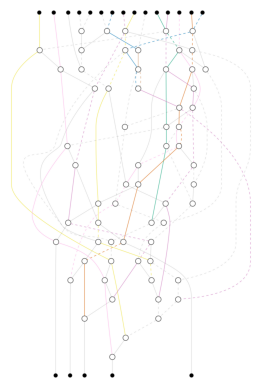

In [33]:
import landauer.graph as graph

graph.show(graph.paper(energy_oriented))

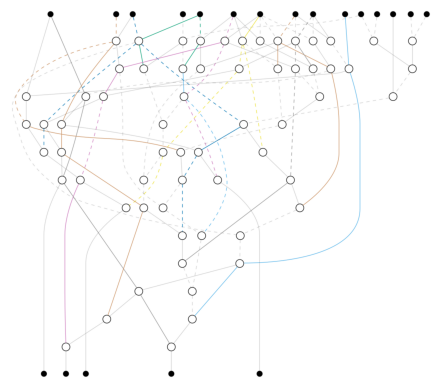

In [34]:
graph.show(graph.paper(depth_oriented))

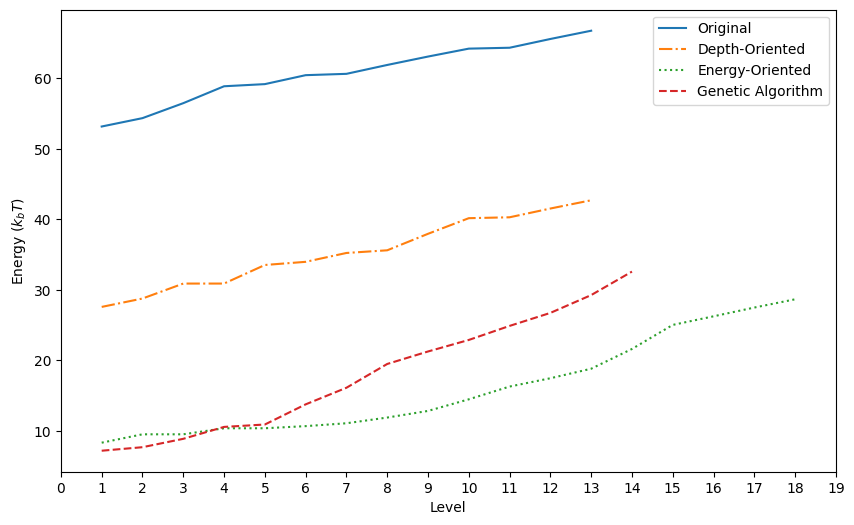

In [46]:

import matplotlib.pyplot as plt 
import numpy as np 

def build_curve(aig, entropy_losses, label, linestyle):
    gates_per_depth = {}
    for gate in entropy_losses.keys():
        depth = node_depth(aig, gate)
        gates_per_depth[depth] = gates_per_depth.get(depth, 0) + entropy_losses[gate]

    x = sorted(gates_per_depth.keys())
    y = []

    for level in x:
        cumulative_loss = 0 if len(y) == 0 else y[-1]
        y.append(cumulative_loss + gates_per_depth[level])
    
    plt.plot(x, y, label = label, linestyle = linestyle) 
    return x, y



plt.figure(figsize=(10, 6))

build_curve(aig, eval_original['gates'], 'Original', '-')
build_curve(depth_oriented, eval_depth['gates'], 'Depth-Oriented', '-.')
build_curve(energy_oriented, eval_energy['gates'], 'Energy-Oriented', ':')
build_curve(genetic_result, eval_genetic['gates'], 'Genetic Algorithm', '--')


plt.xticks(range(0, len(nx.dag_longest_path(energy_oriented))))
plt.xlabel("Level")
plt.ylabel("Energy " + r'$(k_bT)$')
plt.legend() 
plt.savefig('cumulative_loss.png')


Salva netlists e pareto

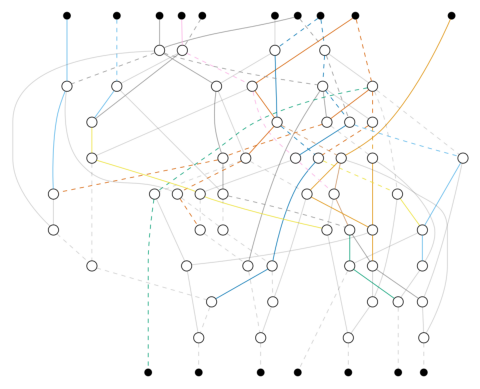

In [7]:
import landauer.plot as plot
import landauer.summary as summary
import landauer.graph as graph


# Plota fronteira de Pareto
def plot_pareto(samples, aig, entropy_data):    
    p = plot.Plot()
    p.plot_samples(samples, 'Genetic Algorithm', legend=False, size=5, color='black')
    p.plot_naive(aig, entropy_data)
    p.plot_pareto(samples)


# Armazena individuos produzidos
solutions = list(map(lambda x: x.forwarding, results['solutions']))

# Armazena imagem do pareto
samples = list()
for forwarding in solutions:
    details = summary.summary(forwarding, entropy_data)
    samples.append((details['entropy_losses'], details['depth']))

plot_pareto(samples, aig, entropy_data)
plt.savefig('genetic_algorithm_x2_pareto.png')
plt.cla()
plt.clf()

# Salva imagem da netlist
middle = results['pareto_info']['middle']
graph.save(graph.paper(middle.forwarding), 'genetic_algorithm_mcnc_x2.png')